epoch    0 | loss 142.4725 | w 1.321 | b 0.208
epoch  100 | loss   0.8811 | w 2.032 | b 0.706
epoch  200 | loss   0.8311 | w 1.999 | b 0.923
epoch  300 | loss   0.8146 | w 1.980 | b 1.048
epoch  400 | loss   0.8092 | w 1.969 | b 1.119
epoch  500 | loss   0.8075 | w 1.962 | b 1.160
epoch  600 | loss   0.8069 | w 1.959 | b 1.184
epoch  700 | loss   0.8067 | w 1.957 | b 1.197
epoch  800 | loss   0.8066 | w 1.956 | b 1.205
epoch  900 | loss   0.8066 | w 1.955 | b 1.209

最终学到：w=1.955, b=1.212（真实值 w=2, b=1）


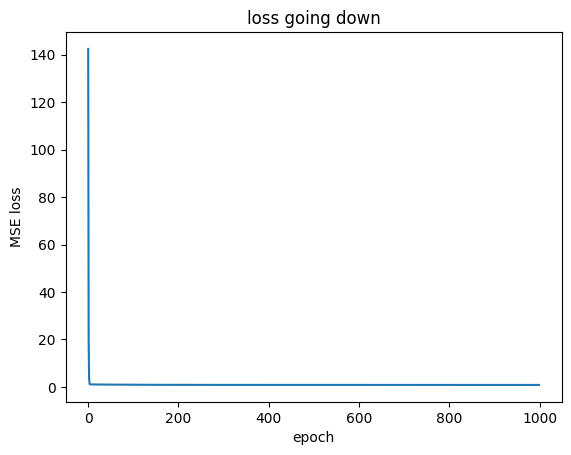

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1. 数据（和 Day 1 一样）----------
np.random.seed(42)
n = 100
X = np.random.rand(n, 1) * 10
true_w, true_b = 2.0, 1.0
y = true_w * X + true_b + np.random.randn(n, 1)   # 真实规律 y = 2x + 1 + 噪声

# ---------- 2. 初始化参数 + 超参数 ----------
w, b = 0.0, 0.0        # 从 0 开始（故意猜得很烂，看它能不能学好）
lr = 0.01              # 学习率
epochs = 1000          # 训练轮数
loss_history = []      # 记录每轮的损失，方便画图

# ---------- 3. 训练循环（梯度下降主体）----------
for epoch in range(epochs):
    # (a) 前向：算预测
    y_pred = w * X + b                      # 形状 (100,1)
    # (b) 算损失
    loss = np.mean((y_pred - y) ** 2)
    loss_history.append(loss)
    # (c) 算梯度（就是第四节推的两个公式）
    error = y_pred - y                       # (ŷ - y)，形状 (100,1)
    grad_w = (2/n) * np.sum(error * X)       # ∂L/∂w = (2/n)Σ(ŷ-y)·x
    grad_b = (2/n) * np.sum(error)           # ∂L/∂b = (2/n)Σ(ŷ-y)
    # (d) 更新参数（朝负梯度走一步）
    w = w - lr * grad_w
    b = b - lr * grad_b
    # 每 100 轮打印一次进度
    if epoch % 100 == 0:
        print(f"epoch {epoch:4d} | loss {loss:8.4f} | w {w:.3f} | b {b:.3f}")

print(f"\n最终学到：w={w:.3f}, b={b:.3f}（真实值 w=2, b=1）")

# ---------- 4. 画损失下降曲线 ----------
plt.plot(loss_history)
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.title("loss going down")
plt.show()